# ImfitDummy

Minimal image fitting program for testing things

## Function definitions

In [1]:
import numpy as np
from matplotlib import pyplot as plt
from lib.imageRead import readImage
from lib.imageProcess import calcOD as calcOD_class

In [2]:
def load_image(mode, path):
    reader = readImage(mode, path)
    reader.updateAll()
    return {"metadata": reader.metadata, "data": reader.frames, "file": reader, "mode": mode}

def calc_OD(image, species, region):
    return calcOD_class(image["file"], species, image["mode"], region).ODCorrected

## Sample script

c:\Users\tide8898\OneDrive - UCB-O365\Documents\Analysis_Software\imfitDue_GaussianWing_bugfix\imfitDue\lib\imfitFunctions.py:60: RuntimeWarning: divide by zero encountered in divide
  -((XR - x0R) ** 2.0) / (2.0 * p[3] ** 2.0)
c:\Users\tide8898\OneDrive - UCB-O365\Documents\Analysis_Software\imfitDue_GaussianWing_bugfix\imfitDue\lib\imfitFunctions.py:60: RuntimeWarning: invalid value encountered in divide
  -((XR - x0R) ** 2.0) / (2.0 * p[3] ** 2.0)
c:\Users\tide8898\OneDrive - UCB-O365\Documents\Analysis_Software\imfitDue_GaussianWing_bugfix\imfitDue\lib\imfitFunctions.py:61: RuntimeWarning: divide by zero encountered in divide
  - (YR - y0R) ** 2.0 / (2.0 * p[5] ** 2.0)
c:\Users\tide8898\OneDrive - UCB-O365\Documents\Analysis_Software\imfitDue_GaussianWing_bugfix\imfitDue\lib\imfitFunctions.py:61: RuntimeWarning: invalid value encountered in divide
  - (YR - y0R) ** 2.0 / (2.0 * p[5] ** 2.0)


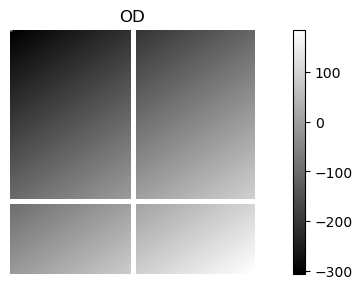

In [ ]:
from lib.imfitFunctions import gaussian_mask_sigma
from scipy.optimize import least_squares


test = [1, 0, 50, 1e-9, 70, 1e-9, 0, 2, 3]
x1 = np.arange(0, 100)
y1 = np.arange(0, 100)
r = [x1, y1]

### Parameters: [offset, amplitude, x0, wx, y0, wy, theta, dODdx, dODdy]
OD2 = gaussian_mask_sigma(test,
                    r,
                    0,
                    mask_radius_x=1e-9,
                    mask_radius_y=1e-9,
                    x0_mask=np.abs(0),
                    y0_mask=np.abs(0),
                    theta_mask=np.abs(0),)

# Plot results
fig, axs = plt.subplots(1, 1, figsize=(8, 3))

plt.colorbar(axs.imshow(OD2.reshape(100,100), cmap="gray"))
axs.set_title("OD")
axs.axis("off")

plt.tight_layout()
plt.show()